# Neural Network with Consolidated Categories

In [5]:

#%pip install pandas matplotlib seaborn scikit-learn tensorflow

In [6]:
import pandas as pd
# if in codespace swap path 1 for path 2
path = r'..\data\cleaned_data_with_parent.csv'
# path = r'./data/cleaned_data_with_parent.csv'

data = pd.read_csv(path)

In [7]:
data['parent_category'].value_counts(normalize=True)*100

parent_category
7     17.598996
6     15.780189
12    11.017921
1      7.691083
10     7.296244
8      6.956173
3      6.176047
0      4.735522
5      4.692853
13     4.196757
14     3.827392
9      3.293722
4      2.565180
11     2.101563
2      2.070358
Name: proportion, dtype: float64

In [8]:
data_unencoded = pd.read_csv(r'../data/data_unencoded.csv')

data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]

data['Order Date'] = pd.to_datetime(data['Order Date'])
data = data.sort_values(by=['Survey ResponseID', 'Order Date'])
data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)

data['Days_Since_Last_Purchase'] = data.groupby('Survey ResponseID')['Order Date'].diff().dt.days.fillna(0)

data = data.drop(columns=['Order Date'])

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['Survey ResponseID'] = encoder.fit_transform(data['Survey ResponseID'])

from sklearn.preprocessing import StandardScaler

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

train_cats = set(train['Category'].unique())
test_cats = set(test['Category'].unique())
unseen = test_cats - train_cats
if len(unseen) > 0:
    test = test[~test['Category'].isin(unseen)]


data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category', 'Purchase Price Per Unit'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)', 'Category', 'Purchase Price Per Unit'], axis=1)

X_train = data_limited_train.drop('parent_category', axis=1)
y_train = data_limited_train['parent_category']
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test = data_limited_test.drop('parent_category', axis=1)
y_test = data_limited_test['parent_category']
X_test_scaled = StandardScaler().fit_transform(X_test)

X_train = X_train.drop(X_train.filter(regex='^Shipping Address').columns, axis=1)
X_test = X_test.drop(X_test.filter(regex='^Shipping Address').columns, axis=1)

X_train = X_train.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])
X_test = X_test.drop(columns = ['diabetes_No', 'wheelchair_No', 'marijuana_No', 'sexual-orientation_heterosexual (straight)', 
                                  'gender_Female', 'alcohol_No'])

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)

C:\Users\shaha\AppData\Local\Temp\ipykernel_16508\80156945.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['Survey ResponseID', 'Order Date']] = data_unencoded[['Survey ResponseID', 'Order Date']]
C:\Users\shaha\AppData\Local\Temp\ipykernel_16508\80156945.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Purchase_Order'] = data.groupby('Survey ResponseID')['Order Date'].rank(method='first').astype(int)
C:\Users\shaha\AppData\Local\Temp\ipykernel_16508\80156945.py:9: PerformanceWarning: DataFrame is highly fragm

In [9]:
X_train.shape

(113655, 101)

In [10]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(101, )))

model.add(tf.keras.layers.Dense(300, activation="relu")) 

model.add(tf.keras.layers.Dense(100, activation="relu"))

model.add(tf.keras.layers.Dense(15, activation="softmax")) 

c:\Users\shaha\Documents\1. SU Masters\Code Space\group-project-bas-team\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │        30,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,215 (243.03 KB)

 Trainable params: 62,215 (243.03 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy", tf.keras.metrics.F1Score(average="weighted")]) # weighted accounts for class imbalance

In [13]:
history = model.fit(X_train_scaled, y_train, epochs=30, shuffle=False)

Epoch 1/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 881us/step - accuracy: 0.2316 - f1_score: 0.1283 - loss: 2.4151
Epoch 2/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 866us/step - accuracy: 0.2495 - f1_score: 0.1285 - loss: 2.3462
Epoch 3/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 872us/step - accuracy: 0.2582 - f1_score: 0.1288 - loss: 2.3162
Epoch 4/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 874us/step - accuracy: 0.2636 - f1_score: 0.1290 - loss: 2.2976
Epoch 5/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 877us/step - accuracy: 0.2679 - f1_score: 0.1291 - loss: 2.2844
Epoch 6/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 881us/step - accuracy: 0.2714 - f1_score: 0.1292 - loss: 2.2730
Epoch 7/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 865us/step - accuracy: 0.2739 - f1_score: 0.1293 - loss: 2.2643
Epoch 8/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 889us/step - accuracy: 0.2777 - f1_score: 0.1293 - loss: 2.2566
Epoch 9/30
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 3s 878us/step - accuracy: 0.2798 - f1_score: 0.1294 - loss: 2.2500
Epoch 10/30
3552/35

In [14]:
test_loss, test_acc, test_f1 = model.evaluate(X_test_scaled, y_test, verbose=2)
print('\nTest Accuracy:', test_acc)
print('\nTest F1-score:', test_f1)

1355/1355 - 1s - 901us/step - accuracy: 0.2296 - f1_score: 0.1302 - loss: 2.4165

Test Accuracy: 0.22961527109146118

Test F1-score: 0.13015899062156677


Predicting the consolidated categories has improved our accuracy greatly to 27.64%

1355/1355 ━━━━━━━━━━━━━━━━━━━━ 1s 576us/step


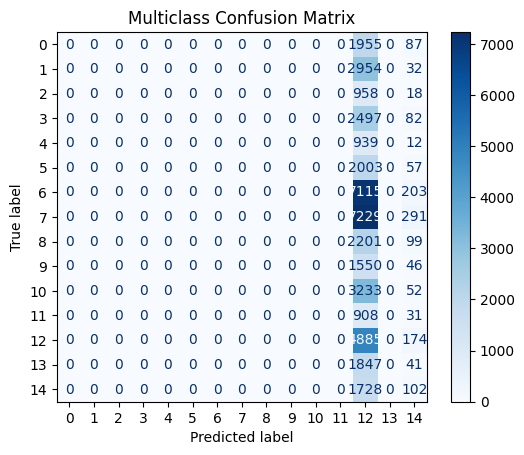

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

However, it seems our model is simply predicting the same class for all instances.

In [18]:
%pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Not

In [19]:
# resampling training data
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

In [20]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(101, )))

model.add(tf.keras.layers.Dense(300, activation="relu")) 

model.add(tf.keras.layers.Dense(100, activation="relu"))

model.add(tf.keras.layers.Dense(15, activation="softmax")) 

c:\Users\shaha\Documents\1. SU Masters\Code Space\group-project-bas-team\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [21]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy", tf.keras.metrics.F1Score(average="weighted")])

In [22]:
history = model.fit(X_train_resampled, y_train_resampled, epochs=30, shuffle=False, verbose=2)

Epoch 1/30
9428/9428 - 9s - 909us/step - accuracy: 0.6857 - f1_score: 0.1318 - loss: 1.0303
Epoch 2/30
9428/9428 - 8s - 853us/step - accuracy: 0.6918 - f1_score: 0.1319 - loss: 1.0013
Epoch 3/30
9428/9428 - 8s - 835us/step - accuracy: 0.6967 - f1_score: 0.1319 - loss: 0.9824
Epoch 4/30
9428/9428 - 8s - 840us/step - accuracy: 0.6990 - f1_score: 0.1319 - loss: 0.9775
Epoch 5/30
9428/9428 - 8s - 838us/step - accuracy: 0.7005 - f1_score: 0.1319 - loss: 0.9721
Epoch 6/30
9428/9428 - 8s - 859us/step - accuracy: 0.7024 - f1_score: 0.1319 - loss: 0.9649
Epoch 7/30
9428/9428 - 8s - 841us/step - accuracy: 0.7026 - f1_score: 0.1319 - loss: 0.9651
Epoch 8/30
9428/9428 - 8s - 838us/step - accuracy: 0.7042 - f1_score: 0.1319 - loss: 0.9609
Epoch 9/30
9428/9428 - 8s - 841us/step - accuracy: 0.7060 - f1_score: 0.1319 - loss: 0.9548
Epoch 10/30
9428/9428 - 8s - 840us/step - accuracy: 0.7058 - f1_score: 0.1319 - loss: 0.9555
Epoch 11/30
9428/9428 - 8s - 830us/step - accuracy: 0.7060 - f1_score: 0.1319 -

In [23]:
test_loss, test_acc, test_f1 = model.evaluate(X_test_scaled, y_test, verbose=2)
print('\nTest Accuracy:', test_acc)
print('\nTest F1-score:', test_f1)

1355/1355 - 1s - 944us/step - accuracy: 0.0422 - f1_score: 0.1170 - loss: 11.3848

Test Accuracy: 0.04223499447107315

Test F1-score: 0.1169891431927681


1355/1355 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step


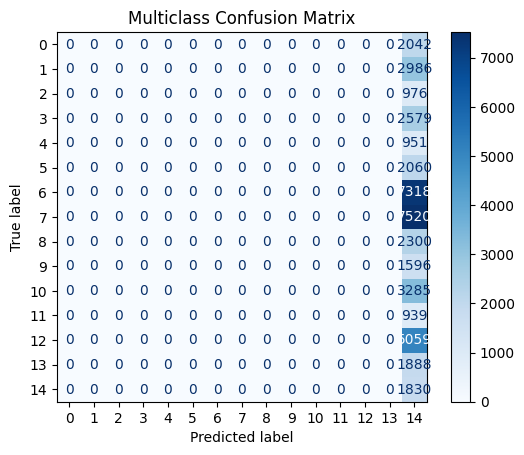

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

class_names_16 = [
    "Kitchen_Home", "Electronics_Accessories", "Industrial_Auto", "Home_Textiles",
    "Consumer_Electronics", "Toys_Games", "Health_Beauty", "Food_Nutrition",
    "Books_Media", "Home_Electrical", "Office_Stationery", "Sports_Fitness",
    "Apparel", "Tools_Hardware", "Home_Decor"
]

print("Classification Report - Neural Network (15 consolidated categories):")
print(classification_report(y_test, y_pred, target_names=class_names_16, zero_division=0))


Classification Report - Neural Network (15 consolidated categories):
                         precision    recall  f1-score   support

           Kitchen_Home       0.00      0.00      0.00      2042
Electronics_Accessories       0.00      0.00      0.00      2986
        Industrial_Auto       0.00      0.00      0.00       976
          Home_Textiles       0.00      0.00      0.00      2579
   Consumer_Electronics       0.00      0.00      0.00       951
             Toys_Games       0.00      0.00      0.00      2060
          Health_Beauty       0.00      0.00      0.00      7318
         Food_Nutrition       0.00      0.00      0.00      7520
            Books_Media       0.00      0.00      0.00      2300
        Home_Electrical       0.00      0.00      0.00      1596
      Office_Stationery       0.00      0.00      0.00      3285
         Sports_Fitness       0.00      0.00      0.00       939
                Apparel       0.00      0.00      0.00      5059
         Tools_Hardw

In [26]:
cm_16 = confusion_matrix(y_test, y_pred)
total_16 = cm_16.sum()
rows_16 = []
for i, name in enumerate(class_names_16):
    if i >= cm_16.shape[0]:
        continue
    tp = int(cm_16[i, i])
    fp = int(cm_16[:, i].sum() - tp)
    fn = int(cm_16[i, :].sum() - tp)
    tn = int(total_16 - tp - fp - fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    rows_16.append({"Class": name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                    "Precision": round(prec,4), "Recall": round(rec,4), "F1": round(f1,4)})

metrics_16 = pd.DataFrame(rows_16).set_index("Class")
print("Per-class TP / TN / FP / FN - Neural Network (15 consolidated categories):")
print(metrics_16.to_string())
print()
print(f"Overall Accuracy: {(y_test == y_pred).mean():.4f}")

from sklearn.metrics import f1_score
print()
print(f"F1 Macro    (unweighted avg over classes): {f1_score(y_test, y_pred, average='macro',    zero_division=0):.4f}")
print(f"F1 Weighted (weighted by class support):   {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Micro    (global TP / FP / FN totals):  {f1_score(y_test, y_pred, average='micro',    zero_division=0):.4f}")


Per-class TP / TN / FP / FN - Neural Network (15 consolidated categories):
                           TP     TN     FP    FN  Precision  Recall     F1
Class                                                                      
Kitchen_Home                0  41287      0  2042     0.0000     0.0  0.000
Electronics_Accessories     0  40343      0  2986     0.0000     0.0  0.000
Industrial_Auto             0  42353      0   976     0.0000     0.0  0.000
Home_Textiles               0  40750      0  2579     0.0000     0.0  0.000
Consumer_Electronics        0  42378      0   951     0.0000     0.0  0.000
Toys_Games                  0  41269      0  2060     0.0000     0.0  0.000
Health_Beauty               0  36011      0  7318     0.0000     0.0  0.000
Food_Nutrition              0  35809      0  7520     0.0000     0.0  0.000
Books_Media                 0  41029      0  2300     0.0000     0.0  0.000
Home_Electrical             0  41733      0  1596     0.0000     0.0  0.000
Office_Statio

Still predicting all one class, but a different class this time.